# Data Processing

This part will handle missing values.
1. We dropped the column of "NMHC(GT)" as over 90% of its data is missing. 
2. We filled missing data with average values. We then standardized the data with Z-Score.
3. We added 12 extra columns recording whether the data missed or not in the original data.

In [ ]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score
)
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings, random

warnings.filterwarnings("ignore")
SEED = 114514
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
set_seed(SEED)

In [ ]:
set_seed(SEED)
df = pd.read_csv(
    "./AirQualityUCI.csv", 
    sep=";", 
    na_values=["", "-200"], 
    keep_default_na=False
)
# Dropping empty rows und columns
df = df.dropna(axis=1, how="all")
df = df.dropna(axis=0, how="all")
print(f"Size: {len(df)}")

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100
missing_info = pd.DataFrame({
    "Null Amount": missing_count,
    "Null Percentage": missing_percent.round(2)
})
print(missing_info[missing_info["Null Amount"] > 0])

if "NMHC(GT)" in df.columns: del df["NMHC(GT)"] # It is a 90%+ missing column, so we just delete it.

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100
missing_info = pd.DataFrame({
    "Null Amount": missing_count,
    "Null Percentage": missing_percent.round(2)
})
print("\nNMHC(GT) Dropped\n")
print(missing_info[missing_info["Null Amount"] > 0])

# Changing the ,s into .s.
for col in df.columns:
    if col not in ["Date", "Time"]:
        try: df[col] = df[col].str.replace(",", ".").astype(float)
        except (AttributeError, ValueError): pass

# Filling nulls by avr
for col in df.columns:
    if col not in ["Date", "Time"]:
        df[f"{col}_missing"] = df[col].isnull().astype(int)
        df[col] = df[col].fillna(df[col].mean())

# clipping outliers to IQR boundaries

numeric_cols = [col for col in df.columns 
                if not (col in ["Date", "Time"] or col.endswith("_missing"))]

affected_counts = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    too_low  = df[col] < lower_bound
    too_high = df[col] > upper_bound
    n_low  = too_low.sum()
    n_high = too_high.sum()
    
    if n_low + n_high > 0:
        affected_counts[col] = (n_low, n_high, lower_bound, upper_bound)
        print(f"  {col:18} → clipped {n_low:4} low values to {lower_bound:.3f} | "
              f"{n_high:4} high values to {upper_bound:.3f}")

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    
total_clipped = sum(low + high for low, high, _, _ in affected_counts.values())
print(f"\nTotal values clipped: {total_clipped} (across all columns)")
print(f"Rows remain unchanged: {len(df)}\n")

# Z-score
numeric_cols = [col for col in df.columns if not (col in ["Date", "Time"] or col.endswith("_missing"))]
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.to_csv("./AirQuality_processed.csv", index=False)
print(f"\nProcessed data: size: {len(df)} columns: {len(df.columns)}")
print(f"\nHead: \n{df.head()}")

Size: 9357
               Null Amount  Null Percentage
CO(GT)                1592            17.01
PT08.S1(CO)            366             3.91
NMHC(GT)              8443            90.23
PT08.S2(NMHC)          366             3.91
NOx(GT)               1639            17.52
PT08.S3(NOx)           366             3.91
NO2(GT)               1642            17.55
PT08.S4(NO2)           366             3.91
PT08.S5(O3)            366             3.91
T                      366             3.91
RH                     366             3.91
AH                     366             3.91

NMHC(GT) Dropped

               Null Amount  Null Percentage
CO(GT)                1592            17.01
PT08.S1(CO)            366             3.91
PT08.S2(NMHC)          366             3.91
NOx(GT)               1639            17.52
PT08.S3(NOx)           366             3.91
NO2(GT)               1642            17.55
PT08.S4(NO2)           366             3.91
PT08.S5(O3)            366             3.91
T 

# Visualization (t-SNE)

We did the thing in both 2d and 3d, containing and not containing the missing columns.

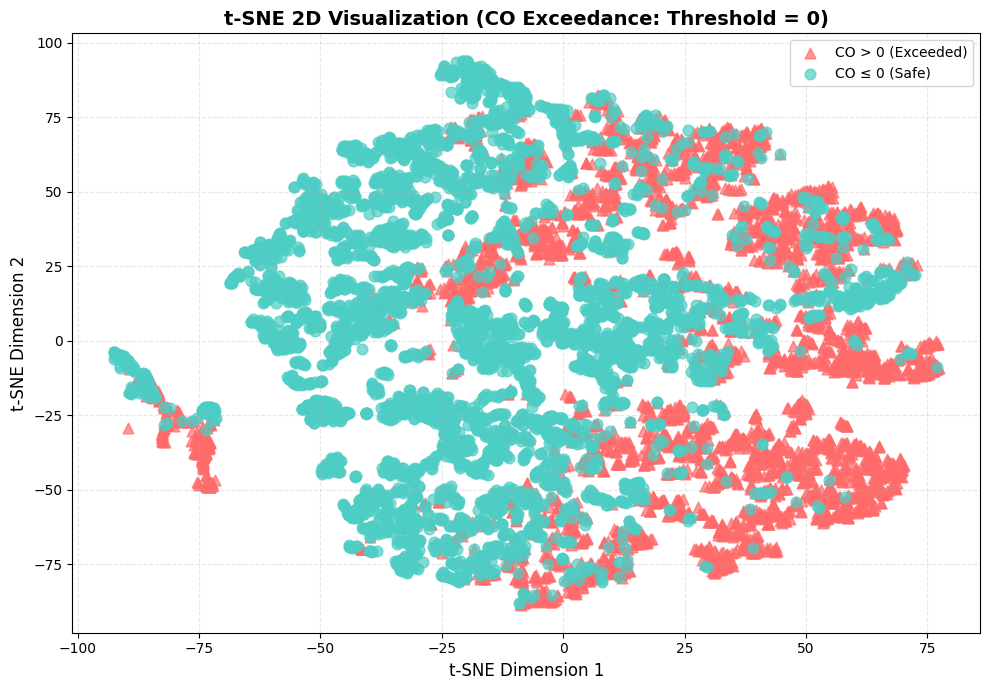

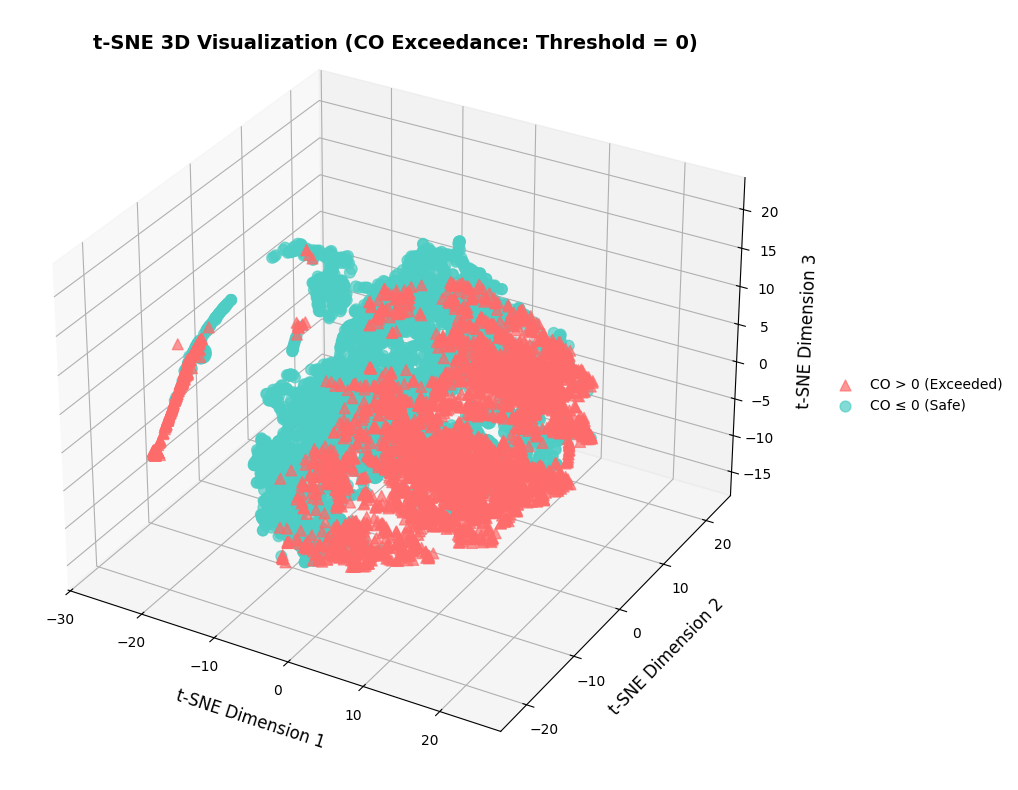

In [ ]:
set_seed(SEED)

def tsne_visualization(tsne_features, df, name=""):
    tsne_2d = TSNE(
        n_components=2,
        perplexity=30,
        random_state=SEED,
        n_iter=1000
    )
    tsne_2d_result = tsne_2d.fit_transform(tsne_features)

    tsne_3d = TSNE(
        n_components=3,
        perplexity=30,
        random_state=SEED,
        n_iter=1000
    )
    tsne_3d_result = tsne_3d.fit_transform(tsne_features)

    colors = {"CO ≤ 0 (Safe)": "#4ECDC4", "CO > 0 (Exceeded)": "#FF6B6B"}
    markers = {"CO ≤ 0 (Safe)": "o", "CO > 0 (Exceeded)": "^"}

    plt.figure(figsize=(10, 7))
    for label in df['CO_Label'].dropna().unique():
        mask = df['CO_Label'] == label
        plt.scatter(
            tsne_2d_result[mask, 0],
            tsne_2d_result[mask, 1],
            c=colors[label],
            marker=markers[label],
            label=label,
            alpha=0.7, 
            s=60 
        )

    plt.title("t-SNE 2D Visualization (CO Exceedance: Threshold = 0)", fontsize=14, fontweight="bold")
    plt.xlabel("t-SNE Dimension 1", fontsize=12)
    plt.ylabel("t-SNE Dimension 2", fontsize=12)
    plt.legend(loc="best", fontsize=10)
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.savefig(f"tsne_2d_air_quality_{name}.png", dpi=300, bbox_inches="tight") 
    plt.show()

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    for label in df['CO_Label'].dropna().unique():
        mask = df['CO_Label'] == label
        ax.scatter(
            tsne_3d_result[mask, 0],
            tsne_3d_result[mask, 1],
            tsne_3d_result[mask, 2],
            c=colors[label],
            marker=markers[label],
            label=label,
            alpha=0.7,
            s=60
        )

    ax.set_title("t-SNE 3D Visualization (CO Exceedance: Threshold = 0)", fontsize=14, fontweight="bold", y=1.02)
    ax.set_xlabel("t-SNE Dimension 1", fontsize=12, labelpad=10)
    ax.set_ylabel("t-SNE Dimension 2", fontsize=12, labelpad=10)
    ax.set_zlabel("t-SNE Dimension 3", fontsize=12, labelpad=10)

    ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=10, frameon=False)
    plt.subplots_adjust(right=0.8)
    plt.tight_layout()
    plt.savefig(f"tsne_3d_air_quality_{name}.png", dpi=300, bbox_inches="tight")
    plt.show()

df = pd.read_csv("./AirQuality_processed.csv")

df['CO_Label'] = np.where(df['CO(GT)'] > 0, "CO > 0 (Exceeded)", "CO ≤ 0 (Safe)")

exclude_cols = ["Date", "Time", "Hour", "Time_Label", "CO(GT)", "CO_Label"]

tsne_features_without_missing = df.drop(
    [col for col in df.columns if col in exclude_cols or col.endswith("_missing")], 
    axis=1
)
tsne_visualization(tsne_features_without_missing, df, "without_missing_CO")

# Clustering 

We would try both K-means and Hierarchical clustering, and evaluate them.

Clustering: 12 columns
Samples: 9357 rows
k=2 | Inertia=72918.20 | sil_score=0.3109
k=3 | Inertia=60622.76 | sil_score=0.2222
k=4 | Inertia=52387.44 | sil_score=0.2198
k=5 | Inertia=47138.50 | sil_score=0.2008
k=6 | Inertia=43378.16 | sil_score=0.1953
k=7 | Inertia=41015.54 | sil_score=0.1806
k=8 | Inertia=38272.83 | sil_score=0.1848
k=9 | Inertia=37281.79 | sil_score=0.1748
k=10 | Inertia=35174.59 | sil_score=0.1766
k=11 | Inertia=34050.57 | sil_score=0.1824
k=12 | Inertia=32426.54 | sil_score=0.1796
k=13 | Inertia=31537.04 | sil_score=0.1726
k=14 | Inertia=30308.19 | sil_score=0.1802
k=15 | Inertia=29425.38 | sil_score=0.1759
k=16 | Inertia=27779.28 | sil_score=0.1901
k=17 | Inertia=26951.91 | sil_score=0.1986
k=18 | Inertia=26084.52 | sil_score=0.2016
k=19 | Inertia=25422.20 | sil_score=0.2002
k=20 | Inertia=24874.25 | sil_score=0.2010


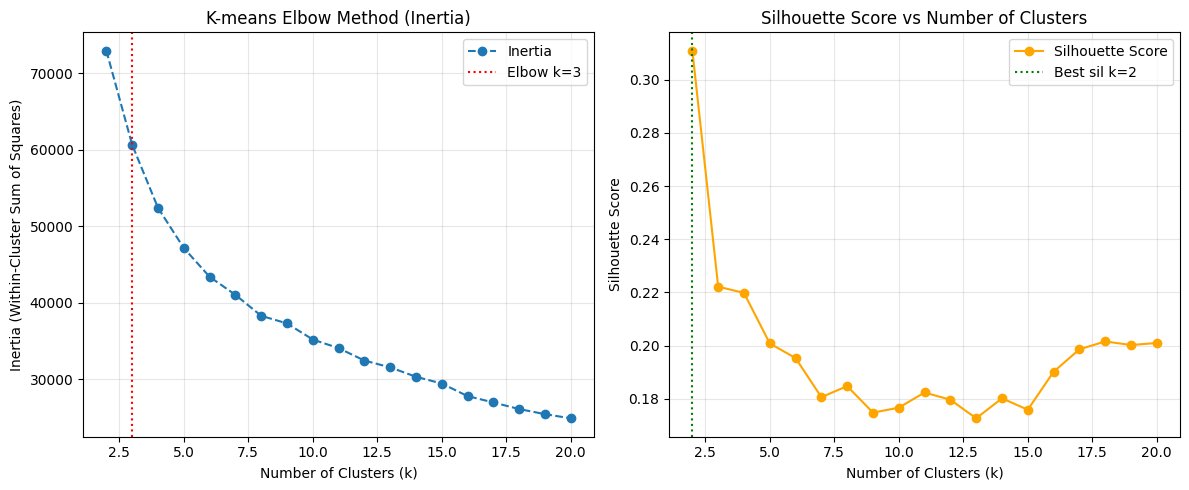


Optimal k by elbow: 3
Optimal k by silhouette score: 2


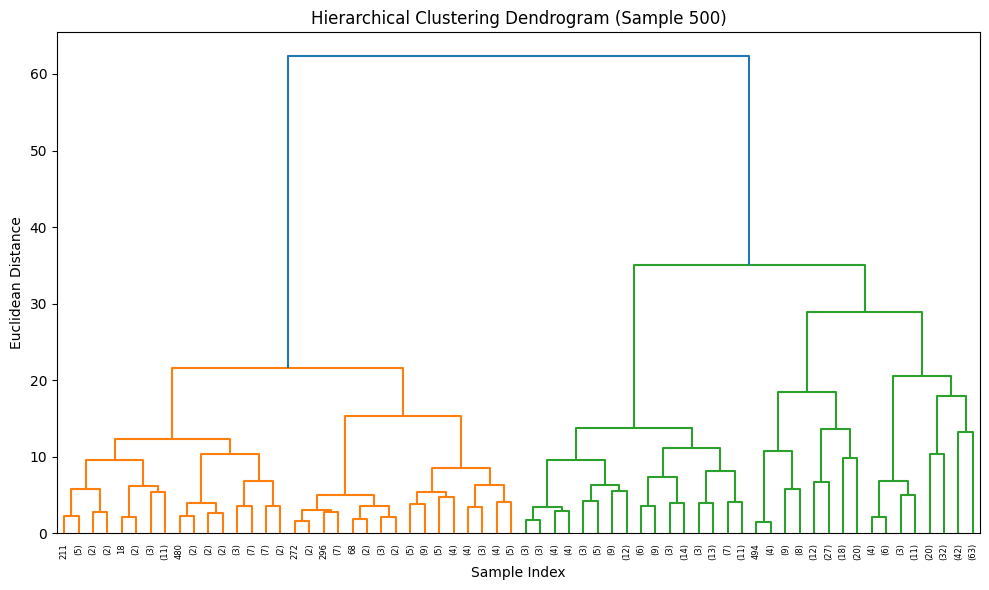


=== K-means Evaluation ===
Silhouette Score: 0.2222
Calinski-Harabasz Score: 3985.6372
Davies-Bouldin Score: 1.4969

=== Hierarchical Evaluation ===
Silhouette Score: 0.1468
Calinski-Harabasz Score: 3105.1296
Davies-Bouldin Score: 1.8756

Evaluation of Clustering:
                    Metric      K-means  Hierarchical
0         Silhouette Score     0.222177      0.146847
1  Calinski-Harabasz Score  3985.637249   3105.129622
2     Davies-Bouldin Score     1.496935      1.875648


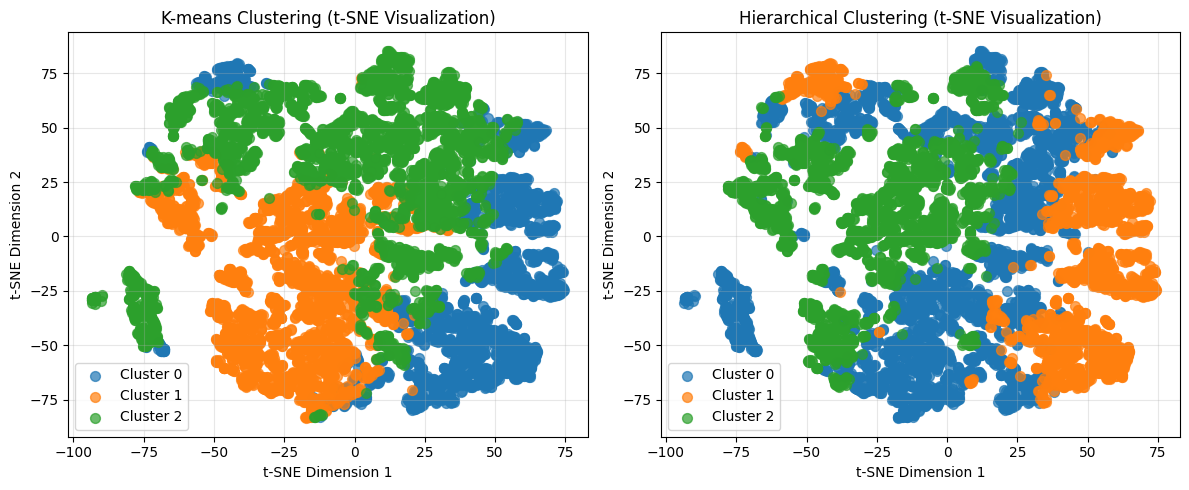

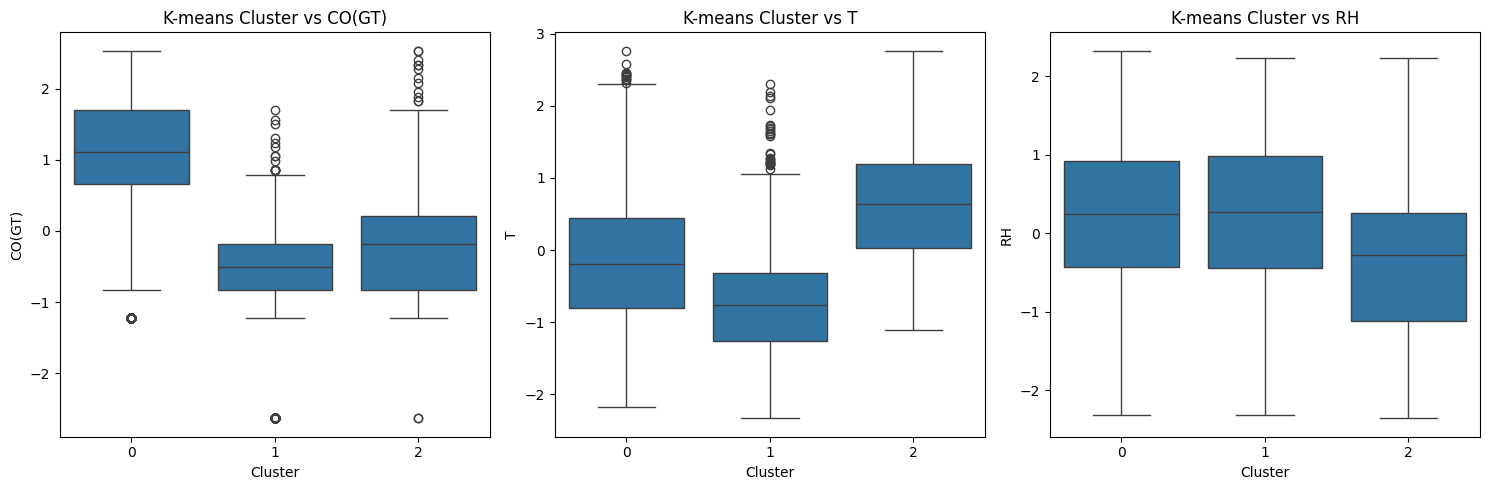

Better algorithm: K-means
This is because:
1. Silhouette Score: K-means (0.2222) > Hierarchical Clustering (0.1468), indicating that K-means clustering has better sample cohesion and separation;
2. CH Score: K-means (3985.6372) > Hierarchical Clustering (3105.1296), indicating that K-means has larger inter-cluster differences and smaller intra-cluster differences;
3. DB Score: K-means (1.4969) < Hierarchical Clustering (1.8756), indicating that K-means clustering results are more compact with less inter-cluster overlap;



In [ ]:
set_seed(SEED)
df = pd.read_csv('./AirQuality_processed.csv')

exclude_cols = ['Date', 'Time', 'Hour', 'Time_Label']
cluster_features = df[
    [col for col in df.columns if col not in exclude_cols and not col.endswith("_missing")]
]

scaler = StandardScaler()
cluster_features_scaled = scaler.fit_transform(cluster_features)

print(f"Clustering: {cluster_features_scaled.shape[1]} columns")
print(f"Samples: {cluster_features_scaled.shape[0]} rows")

# finding best k
def find_optimal_k(data, max_k=20, min_k=2):
    inertia = [] 
    silhouette_scores = [] 

    for k in range(min_k, max_k+1):
        kmeans = KMeans(n_clusters=k, random_state=SEED, n_init='auto') 
        labels = kmeans.fit_predict(data)
        inertia.append(kmeans.inertia_)
        sil_score = silhouette_score(data, labels)
        silhouette_scores.append(sil_score)
        print(f"k={k} | Inertia={inertia[-1]:.2f} | sil_score={sil_score:.4f}")

    first_derivative = np.diff(inertia)
    second_derivative = np.diff(first_derivative)
    elbow_k = min_k + np.argmax(second_derivative) + 1 

    best_sil_k = min_k + np.argmax(silhouette_scores)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(min_k, max_k+1), inertia, marker='o', linestyle='--', label='Inertia')
    plt.axvline(x=elbow_k, color='red', linestyle=':', label=f'Elbow k={elbow_k}')
    plt.title('K-means Elbow Method (Inertia)', fontsize=12)
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
    plt.grid(alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(min_k, max_k+1), silhouette_scores, marker='o', color='orange', label='Silhouette Score')
    plt.axvline(x=best_sil_k, color='green', linestyle=':', label=f'Best sil k={best_sil_k}')
    plt.title('Silhouette Score vs Number of Clusters', fontsize=12)
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig('optimal_k_detection.png', dpi=300)
    plt.show()

    print(f"\nOptimal k by elbow: {elbow_k}")
    print(f"Optimal k by silhouette score: {best_sil_k}")

    return elbow_k 
    # return best_sil_k

optimal_k = find_optimal_k(cluster_features_scaled, max_k=20)

# k-means
kmeans = KMeans(n_clusters=optimal_k, random_state=SEED)
kmeans_labels = kmeans.fit_predict(cluster_features_scaled)
df['KMeans_Cluster'] = kmeans_labels

hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(cluster_features_scaled)
df['Hierarchical_Cluster'] = hierarchical_labels

# tree-like graph of hierarchical clustering
plt.figure(figsize=(10, 6))
sample_idx = np.random.choice(len(cluster_features_scaled), 500, replace=False)
linkage_matrix = linkage(cluster_features_scaled[sample_idx], method='ward')
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram (Sample 500)', fontsize=12)
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', dpi=300)
plt.show()

# evaluate clustering
def evaluate_clustering(data, labels, algorithm_name):
    metrics = {
        'Silhouette Score': silhouette_score(data, labels),
        'Calinski-Harabasz Score': calinski_harabasz_score(data, labels),
        'Davies-Bouldin Score': davies_bouldin_score(data, labels)
    }
    print(f"\n=== {algorithm_name} Evaluation ===")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    return metrics

kmeans_metrics = evaluate_clustering(cluster_features_scaled, kmeans_labels, 'K-means')
hierarchical_metrics = evaluate_clustering(cluster_features_scaled, hierarchical_labels, 'Hierarchical')

metrics_df = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Calinski-Harabasz Score', 'Davies-Bouldin Score'],
    'K-means': [kmeans_metrics['Silhouette Score'], kmeans_metrics['Calinski-Harabasz Score'], kmeans_metrics['Davies-Bouldin Score']],
    'Hierarchical': [hierarchical_metrics['Silhouette Score'], hierarchical_metrics['Calinski-Harabasz Score'], hierarchical_metrics['Davies-Bouldin Score']]
})
print("\nEvaluation of Clustering:")
print(metrics_df)

# t-SNE
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
tsne_result = tsne.fit_transform(cluster_features_scaled)
df['TSNE_1'] = tsne_result[:, 0]
df['TSNE_2'] = tsne_result[:, 1]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for cluster in range(optimal_k):
    mask = df['KMeans_Cluster'] == cluster
    plt.scatter(df.loc[mask, 'TSNE_1'], df.loc[mask, 'TSNE_2'], label=f'Cluster {cluster}', alpha=0.7, s=50)
plt.title('K-means Clustering (t-SNE Visualization)', fontsize=12)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
for cluster in range(optimal_k):
    mask = df['Hierarchical_Cluster'] == cluster
    plt.scatter(df.loc[mask, 'TSNE_1'], df.loc[mask, 'TSNE_2'], label=f'Cluster {cluster}', alpha=0.7, s=50)
plt.title('Hierarchical Clustering (t-SNE Visualization)', fontsize=12)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('clustering_visualization.png', dpi=300)
plt.show()

core_features = ['CO(GT)', 'T', 'RH']
plt.figure(figsize=(15, 5))
for i, feature in enumerate(core_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='KMeans_Cluster', y=feature, data=df)
    plt.title(f'K-means Cluster vs {feature}', fontsize=12)
    plt.xlabel('Cluster')
    plt.ylabel(feature)
plt.tight_layout()
plt.savefig('cluster_feature_distribution.png', dpi=300)
plt.show()

# Basic Prediction & Model Evaluation and Improvements  
We tried a prediction on whether the CO level is exceeding normal level.  
We used logistic regression and decision tree.  

Model: Logistic Regression


===== Training Set =====
Confusion Matrix:
[[3125  471]
 [ 675 2278]]
Accuracy:     0.8250
Precision:    0.8287
Recall:       0.7714
F1-Score:     0.7990
AUC Score:    0.9060


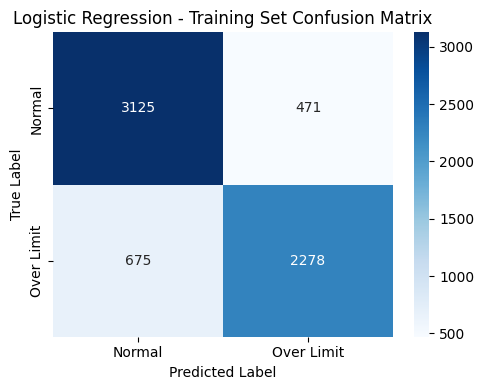


===== Testing Set =====
Confusion Matrix:
[[1355  182]
 [ 310  961]]
Accuracy:     0.8248
Precision:    0.8408
Recall:       0.7561
F1-Score:     0.7962
AUC Score:    0.9116


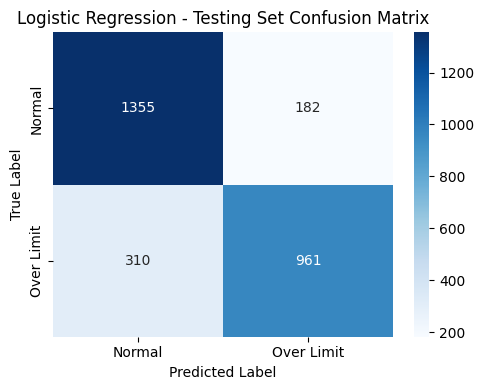


===== Entire Dataset =====
Confusion Matrix:
[[4480  653]
 [ 985 3239]]
Accuracy:     0.8249
Precision:    0.8322
Recall:       0.7668
F1-Score:     0.7982
AUC Score:    0.9076


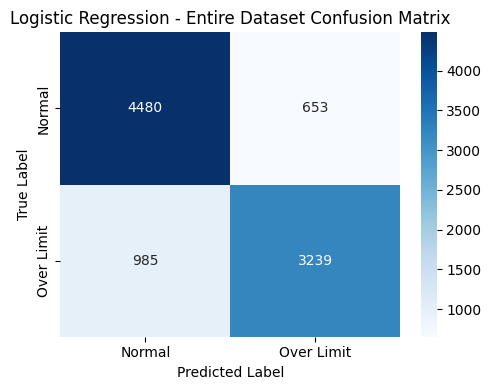

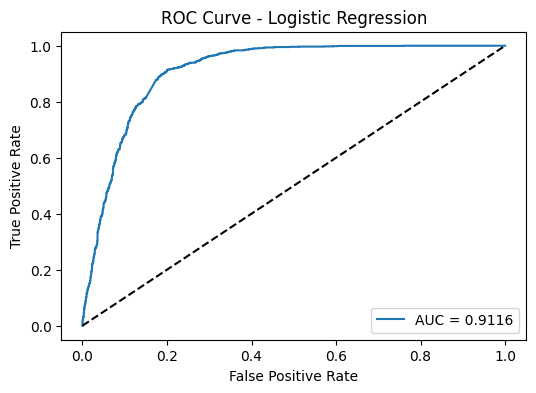


5-fold CV Accuracy: 0.7969 ± 0.0353



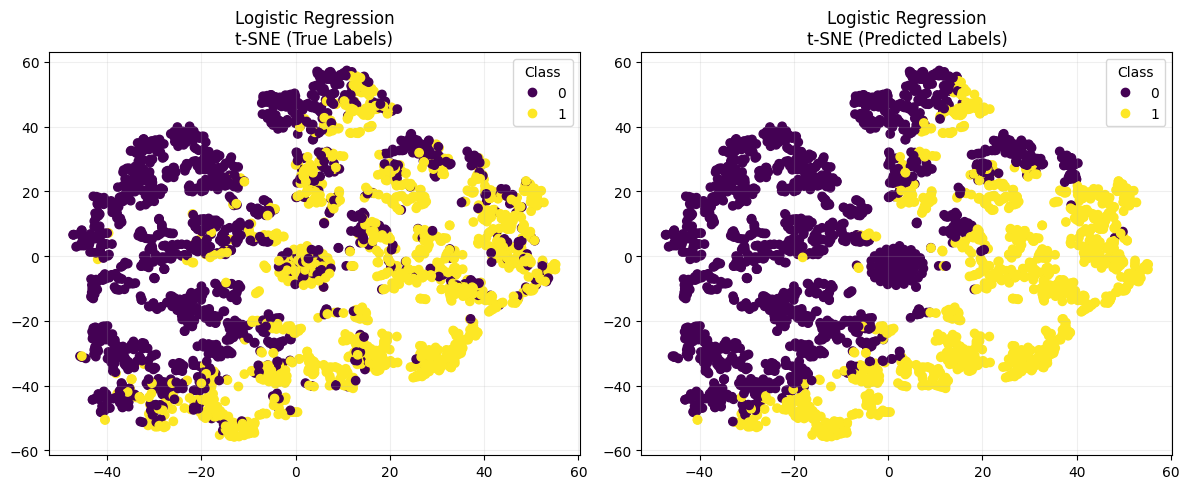

Model: Decision Tree


===== Training Set =====
Confusion Matrix:
[[2648  948]
 [ 175 2778]]
Accuracy:     0.8285
Precision:    0.7456
Recall:       0.9407
F1-Score:     0.8319
AUC Score:    0.9037


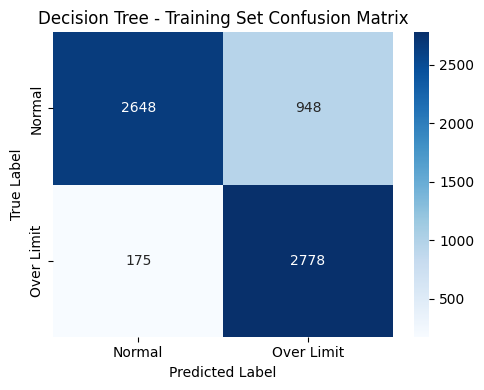


===== Testing Set =====
Confusion Matrix:
[[1140  397]
 [  80 1191]]
Accuracy:     0.8301
Precision:    0.7500
Recall:       0.9371
F1-Score:     0.8332
AUC Score:    0.8934


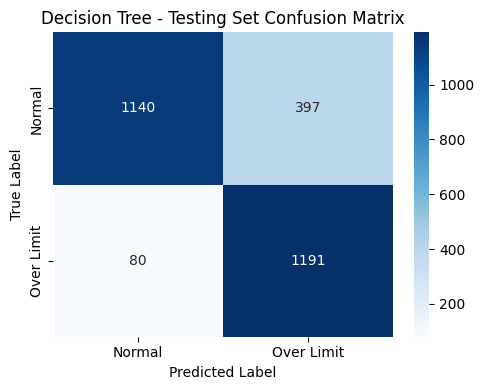


===== Entire Dataset =====
Confusion Matrix:
[[3788 1345]
 [ 255 3969]]
Accuracy:     0.8290
Precision:    0.7469
Recall:       0.9396
F1-Score:     0.8322
AUC Score:    0.9006


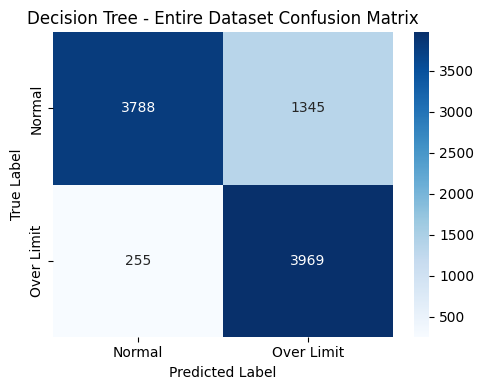

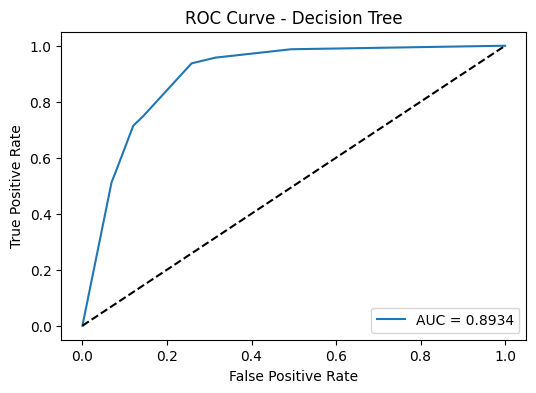


5-fold CV Accuracy: 0.8272 ± 0.0320



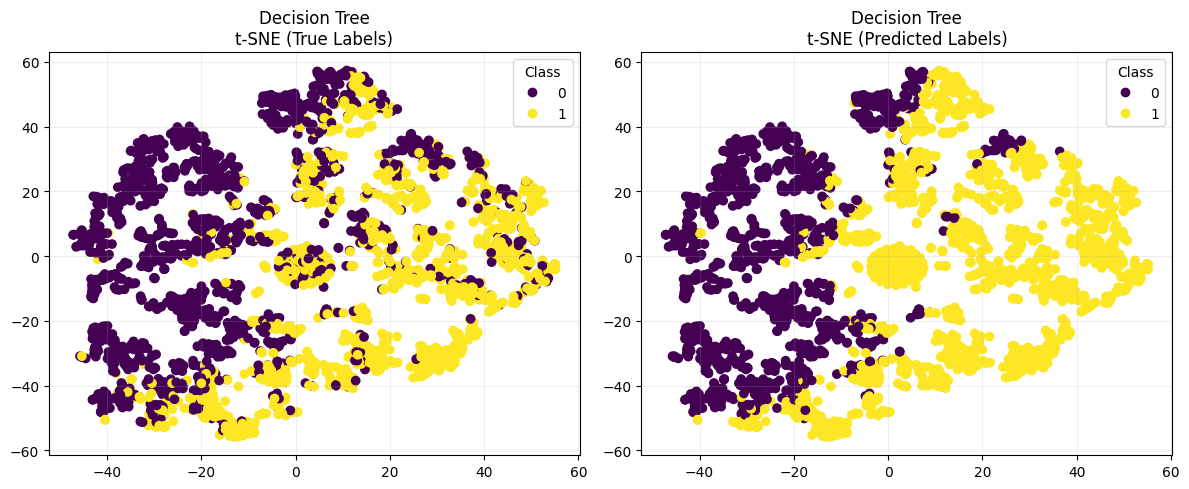

In [94]:
set_seed(SEED)
df = pd.read_csv("./AirQuality_processed.csv")
df["CO_over_limit"] = (df["CO(GT)"] > 0).astype(int)

feature_cols = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH"]
df = df.dropna(subset=feature_cols + ["CO_over_limit"])
X = df[feature_cols]
y = df["CO_over_limit"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=SEED)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=SEED)
}

def evaluate_model(name, model, X_data, y_true, dataset_name):
    y_pred = model.predict(X_data)
    y_pred_proba = model.predict_proba(X_data)[:, 1]

    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_pred_proba)

    print(f"\n===== {dataset_name} =====")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy:     {acc:.4f}")
    print(f"Precision:    {precision:.4f}")
    print(f"Recall:       {recall:.4f}")
    print(f"F1-Score:     {f1:.4f}")
    print(f"AUC Score:    {auc:.4f}")

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Over Limit"], yticklabels=["Normal", "Over Limit"])
    plt.title(f"{name} - {dataset_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    return y_pred, auc

for name, model in models.items():
    print("=" * 80)
    print(f"Model: {name}\n")

    model.fit(X_train, y_train)

    evaluate_model(name, model, X_train, y_train, "Training Set")
    y_pred_test, auc_test = evaluate_model(name, model, X_test, y_test, "Testing Set")
    evaluate_model(name, model, X_scaled, y, "Entire Dataset")

    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {auc_test:.4f}")
    plt.plot([0,1],[0,1],"k--")
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring="accuracy")
    print(f"\n5-fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}\n")

    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    X_test_tsne = tsne.fit_transform(X_test)

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
    ax1.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_test, cmap="coolwarm", alpha=0.6, s=15)
    ax1.set_title(f"{name}\nt-SNE (True Labels)")
    ax1.legend(*ax1.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_test).legend_elements(), title="Class")
    ax1.grid(alpha=0.2)

    ax2.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_pred_test, cmap="coolwarm", alpha=0.6, s=15)
    ax2.set_title(f"{name}\nt-SNE (Predicted Labels)")
    ax2.legend(*ax2.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_pred_test).legend_elements(), title="Class")
    ax2.grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()

After that, We would improve Logistic Regression by using polynomial degree of 2. We would improve the Decision Tree by adding depth.  

Logistic Regression + Polynomial Features

===== Train Set =====
Confusion Matrix:
[[2980  616]
 [ 382 2571]]
Accuracy:  0.8476
Precision: 0.8067
Recall:    0.8706
F1:        0.8375
AUC:       0.9250


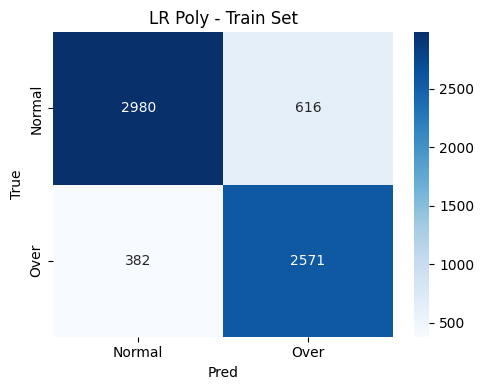


===== Test Set =====
Confusion Matrix:
[[1292  245]
 [ 156 1115]]
Accuracy:  0.8572
Precision: 0.8199
Recall:    0.8773
F1:        0.8476
AUC:       0.9246


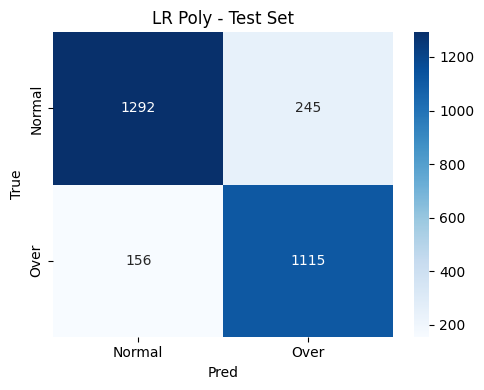


===== Full Set =====
Confusion Matrix:
[[4272  861]
 [ 538 3686]]
Accuracy:  0.8505
Precision: 0.8106
Recall:    0.8726
F1:        0.8405
AUC:       0.9248


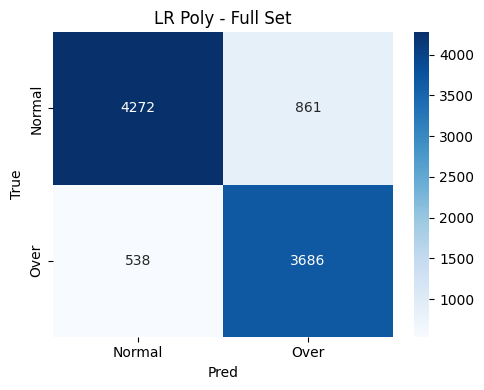

CV Acc: 0.7746 ± 0.0858



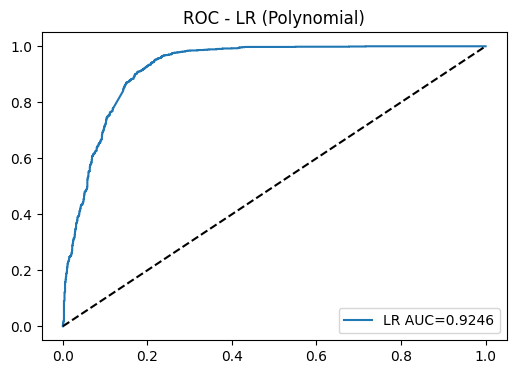

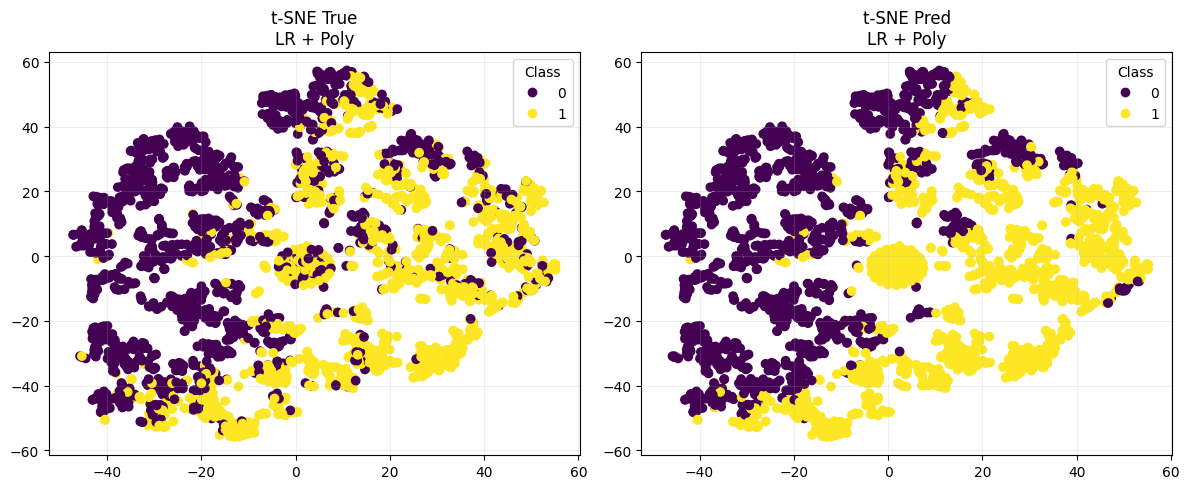

Decision Tree (Tuned max_depth)
Best max_depth = 5

===== Train Set =====
Confusion Matrix:
[[2850  746]
 [ 190 2763]]
Accuracy:  0.8571
Precision: 0.7874
Recall:    0.9357
F1:        0.8552
AUC:       0.9265


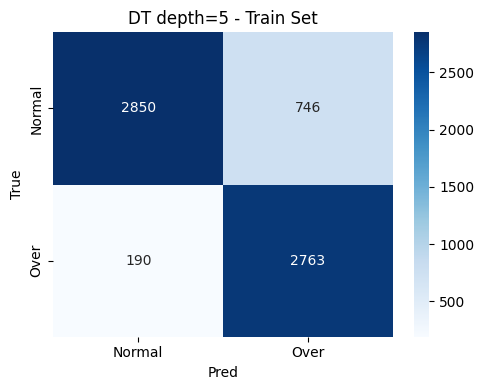


===== Test Set =====
Confusion Matrix:
[[1214  323]
 [ 101 1170]]
Accuracy:  0.8490
Precision: 0.7837
Recall:    0.9205
F1:        0.8466
AUC:       0.9060


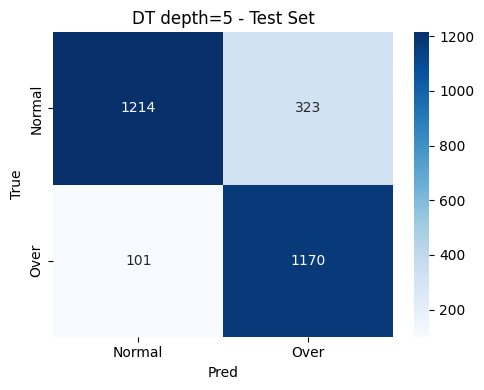


===== Full Set =====
Confusion Matrix:
[[4064 1069]
 [ 291 3933]]
Accuracy:  0.8547
Precision: 0.7863
Recall:    0.9311
F1:        0.8526
AUC:       0.9203


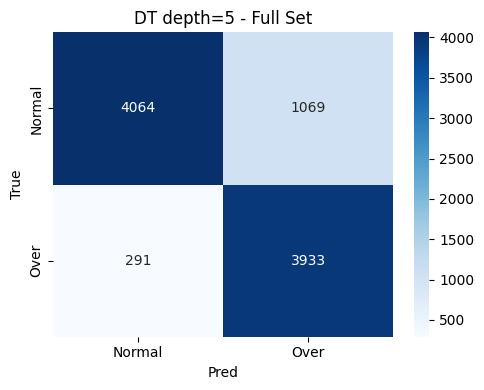

CV Acc: 0.7951 ± 0.0552



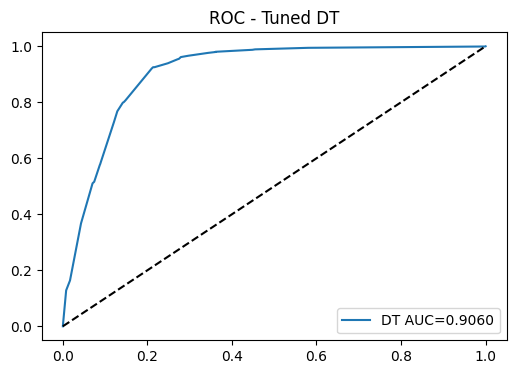

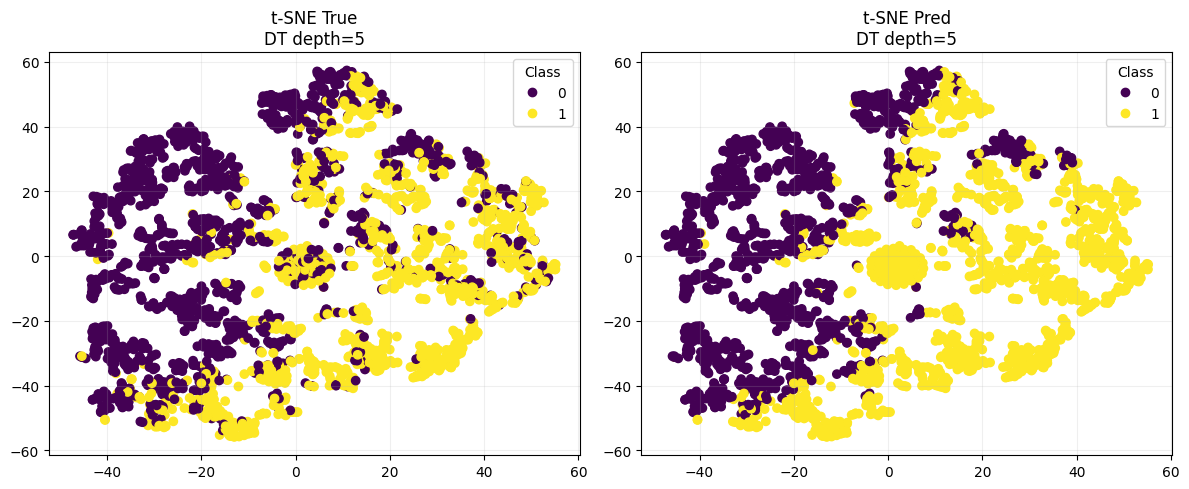

In [95]:
set_seed(SEED)
df = pd.read_csv("./AirQuality_processed.csv")
df["CO_over_limit"] = (df["CO(GT)"] > 0).astype(int)

feature_cols = [
    "PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)",
    "T", "RH", "AH"
]
df = df.dropna(subset=feature_cols + ["CO_over_limit"])
X = df[feature_cols]
y = df["CO_over_limit"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=SEED
)

def evaluate(name, model, X, y_true, dataset):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba)

    print(f"\n===== {dataset} =====")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"AUC:       {auc:.4f}")

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Over'], yticklabels=['Normal', 'Over'])
    plt.title(f'{name} - {dataset}')
    plt.xlabel('Pred')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    return y_pred, auc

print("=" * 70)
print("Logistic Regression + Polynomial Features")

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_all_poly = poly.transform(X_scaled)

lr = LogisticRegression(max_iter=5000, random_state=SEED)
lr.fit(X_train_poly, y_train)

evaluate("LR Poly", lr, X_train_poly, y_train, "Train Set")
y_pred_lr, auc_lr = evaluate("LR Poly", lr, X_test_poly, y_test, "Test Set")
evaluate("LR Poly", lr, X_all_poly, y, "Full Set")

cv_lr = cross_val_score(lr, X_all_poly, y, cv=5, scoring="accuracy")
print(f"CV Acc: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}\n")

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_poly)[:,1])
plt.figure(figsize=(6,4))
plt.plot(fpr_lr, tpr_lr, label=f"LR AUC={auc_lr:.4f}")
plt.plot([0,1],[0,1],"k--")
plt.title("ROC - LR (Polynomial)")
plt.legend()
plt.show()

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_test_tsne = tsne.fit_transform(X_test)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
ax1.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_test, cmap='coolwarm', alpha=0.6, s=15)
ax1.set_title('t-SNE True\nLR + Poly')
ax1.legend(*ax1.scatter(X_test_tsne[:,0],X_test_tsne[:,1],c=y_test).legend_elements(), title='Class')
ax1.grid(alpha=0.2)
ax2.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_pred_lr, cmap='coolwarm', alpha=0.6, s=15)
ax2.set_title('t-SNE Pred\nLR + Poly')
ax2.legend(*ax2.scatter(X_test_tsne[:,0],X_test_tsne[:,1],c=y_pred_lr).legend_elements(), title='Class')
ax2.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("=" * 70)
print("Decision Tree (Tuned max_depth)")

dt = DecisionTreeClassifier(random_state=SEED)
grid = GridSearchCV(dt, {"max_depth":[2,3,4,5,6,7,8,9,10]}, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)
best_dt = grid.best_estimator_
best_depth = grid.best_params_["max_depth"]
print(f"Best max_depth = {best_depth}")

evaluate(f"DT depth={best_depth}", best_dt, X_train, y_train, "Train Set")
y_pred_dt, auc_dt = evaluate(f"DT depth={best_depth}", best_dt, X_test, y_test, "Test Set")
evaluate(f"DT depth={best_depth}", best_dt, X_scaled, y, "Full Set")

cv_dt = cross_val_score(best_dt, X_scaled, y, cv=5, scoring="accuracy")
print(f"CV Acc: {cv_dt.mean():.4f} ± {cv_dt.std():.4f}\n")

fpr_dt, tpr_dt, _ = roc_curve(y_test, best_dt.predict_proba(X_test)[:,1])
plt.figure(figsize=(6,4))
plt.plot(fpr_dt, tpr_dt, label=f"DT AUC={auc_dt:.4f}")
plt.plot([0,1],[0,1],"k--")
plt.title("ROC - Tuned DT")
plt.legend()
plt.show()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
ax1.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_test, cmap='coolwarm', alpha=0.6, s=15)
ax1.set_title(f't-SNE True\nDT depth={best_depth}')
ax1.legend(*ax1.scatter(X_test_tsne[:,0],X_test_tsne[:,1],c=y_test).legend_elements(), title='Class')
ax1.grid(alpha=0.2)
ax2.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_pred_dt, cmap='coolwarm', alpha=0.6, s=15)
ax2.set_title(f't-SNE Pred\nDT depth={best_depth}')
ax2.legend(*ax2.scatter(X_test_tsne[:,0],X_test_tsne[:,1],c=y_pred_dt).legend_elements(), title='Class')
ax2.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Deep Learning Prediction

We expect a better prediction using deep learning methods.  
We would use an LSTM with the past few hours' data to predict the current hour's CO level, and an FNN with the current few hours' data to predict the current hour's CO level.

In [109]:
set_seed(SEED+1)
feature_cols = [
    "PT08.S1(CO)", "PT08.S2(NMHC)", 
    "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)",
    "T", "RH", "AH"
]
df = df.dropna(subset=feature_cols + ["CO_over_limit"])
X = df[feature_cols]
y = df["CO_over_limit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

class AirDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(np.array(X, dtype=np.float32))
        self.y = torch.tensor(np.array(y, dtype=np.int64))
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(AirDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(AirDataset(X_test, y_test), batch_size=32, shuffle=False)
X_all_scaled = scaler.transform(X)
all_loader = DataLoader(AirDataset(X_all_scaled, y), batch_size=32, shuffle=False)

class FNN(nn.Module):
    def __init__(self, input_size=8, num_classes=2):
        super().__init__()
        self.actv = nn.ReLU()

        self.input_block = nn.Sequential(
            nn.Linear(input_size, 32),
            self.actv
        )

        self.hidden_linear = nn.Linear(32, 32)

        self.output_block = nn.Sequential(
            nn.Linear(32, 16),
            self.actv,
            nn.Linear(16, num_classes)
        )

    def forward(self, x): 
        x = self.input_block(x)

        for _ in range(3): # 3 is the best
            residual = x
            x = self.hidden_linear(x) 
            x = x + residual 
            x = self.actv(x) 

        x = self.output_block(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 25

print("Training\n")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1:2d} | Loss: {total_loss/len(train_loader):.4f}")

@torch.no_grad()
def evaluate(loader):
    model.eval()
    y_true, y_pred = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).argmax(1).cpu().numpy()
        y_true.extend(y_batch.numpy())
        y_pred.extend(pred)
    return accuracy_score(y_true, y_pred), classification_report(y_true, y_pred, digits=4)

acc_train, _ = evaluate(train_loader)
acc_test, report = evaluate(test_loader)
acc_all, _ = evaluate(all_loader)

print("\n" + "="*60)
print("FNN:\n")
print(f"Accuracy on TRAIN set: {acc_train:.4f}")
print(f"Accuracy on TEST  set: {acc_test:.4f}")
print(f"Accuracy on ALL   set: {acc_all:.4f}")
print("\nTest set classification report:")
print(report)

Training

Epoch  1 | Loss: 0.4445
Epoch  2 | Loss: 0.3549
Epoch  3 | Loss: 0.3453
Epoch  4 | Loss: 0.3390
Epoch  5 | Loss: 0.3312
Epoch  6 | Loss: 0.3298
Epoch  7 | Loss: 0.3265
Epoch  8 | Loss: 0.3250
Epoch  9 | Loss: 0.3220
Epoch 10 | Loss: 0.3190
Epoch 11 | Loss: 0.3189
Epoch 12 | Loss: 0.3157
Epoch 13 | Loss: 0.3168
Epoch 14 | Loss: 0.3142
Epoch 15 | Loss: 0.3139
Epoch 16 | Loss: 0.3106
Epoch 17 | Loss: 0.3114
Epoch 18 | Loss: 0.3089
Epoch 19 | Loss: 0.3073
Epoch 20 | Loss: 0.3082
Epoch 21 | Loss: 0.3053
Epoch 22 | Loss: 0.3027
Epoch 23 | Loss: 0.3030
Epoch 24 | Loss: 0.3017
Epoch 25 | Loss: 0.3033

FNN:

Accuracy on TRAIN set: 0.8650
Accuracy on TEST  set: 0.8583
Accuracy on ALL   set: 0.8630

Test set classification report:
              precision    recall  f1-score   support

           0     0.8882    0.8478    0.8675      1537
           1     0.8255    0.8710    0.8476      1271

    accuracy                         0.8583      2808
   macro avg     0.8569    0.8594    0.857

In [97]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
fold_results = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
    print(f"\n{'='*50}")
    print(f"FOLD {fold+1} / 5")
    print(f"{'='*50}")

    X = X.drop(columns=["CO(GT)", "CO(GT)_missing"], errors="ignore")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    train_loader = DataLoader(AirDataset(X_train, y_train), batch_size=32, shuffle=True)
    test_loader = DataLoader(AirDataset(X_test, y_test), batch_size=32, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = FNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    epochs = 25

    print("Training...")
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1:2d} | Loss: {total_loss/len(train_loader):.4f}")

    acc_train, _ = evaluate(train_loader)
    acc_test, report = evaluate(test_loader)
    fold_results.append(acc_test)

    print(f"\nFOLD {fold+1} Result")
    print(f"Train Acc: {acc_train:.4f}")
    print(f"Test  Acc: {acc_test:.4f}")

print("\n" + "="*60)
print("5-FOLD RESULT")
print(f"Mean Test Accuracy: {np.mean(fold_results):.4f}")
print(f"Std Test Accuracy:  {np.std(fold_results):.4f}")
print(f"All folds acc: {[round(f,4) for f in fold_results]}")


FOLD 1 / 5
Training...
Epoch  5 | Loss: 0.3291
Epoch 10 | Loss: 0.3189
Epoch 15 | Loss: 0.3058
Epoch 20 | Loss: 0.2983
Epoch 25 | Loss: 0.2906

FOLD 1 Result
Train Acc: 0.8635
Test  Acc: 0.8510

FOLD 2 / 5
Training...
Epoch  5 | Loss: 0.3231
Epoch 10 | Loss: 0.3139
Epoch 15 | Loss: 0.3049
Epoch 20 | Loss: 0.2974
Epoch 25 | Loss: 0.2918

FOLD 2 Result
Train Acc: 0.8709
Test  Acc: 0.8638

FOLD 3 / 5
Training...
Epoch  5 | Loss: 0.3288
Epoch 10 | Loss: 0.3186
Epoch 15 | Loss: 0.3121
Epoch 20 | Loss: 0.3049
Epoch 25 | Loss: 0.2975

FOLD 3 Result
Train Acc: 0.8664
Test  Acc: 0.8594

FOLD 4 / 5
Training...
Epoch  5 | Loss: 0.3301
Epoch 10 | Loss: 0.3153
Epoch 15 | Loss: 0.3078
Epoch 20 | Loss: 0.2982
Epoch 25 | Loss: 0.2945

FOLD 4 Result
Train Acc: 0.8707
Test  Acc: 0.8541

FOLD 5 / 5
Training...
Epoch  5 | Loss: 0.3274
Epoch 10 | Loss: 0.3141
Epoch 15 | Loss: 0.3051
Epoch 20 | Loss: 0.2936
Epoch 25 | Loss: 0.2866

FOLD 5 Result
Train Acc: 0.8734
Test  Acc: 0.8482

5-FOLD RESULT
Mean Test 

In [125]:
set_seed(SEED)
SEQ_LENGTH = 21

feature_cols = [
    "PT08.S1(CO)", "PT08.S2(NMHC)", 
    "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)",
    "T", "RH", "AH"
]
df = df.dropna(subset=feature_cols + ["CO_over_limit"])
X = df[feature_cols]
y = df["CO_over_limit"]

def create_sequences(X, y, seq_len):
    xs, ys = [], []
    for i in range(len(X) - seq_len):
        xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(xs), np.array(ys)

X_seq, y_seq = create_sequences(X, y, SEQ_LENGTH)
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.3, random_state=SEED)

scaler = StandardScaler()
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_reshaped).reshape(X_train.shape)

X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler.transform(X_test_reshaped).reshape(X_test.shape)

X_all_reshaped = X_seq.reshape(-1, X_seq.shape[-1])
X_all_scaled = scaler.transform(X_all_reshaped).reshape(X_seq.shape)

class AirDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(AirDataset(X_train_scaled, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(AirDataset(X_test_scaled, y_test), batch_size=64, shuffle=False)
all_loader = DataLoader(AirDataset(X_all_scaled, y_seq), batch_size=64, shuffle=False)

class LSTM(nn.Module):
    def __init__(self, input_size=8, hidden_size=128, num_layers=3, num_classes=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=False, dropout=0.2)
        self.bn = nn.BatchNorm1d(hidden_size)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.drop = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.bn(out)
        out = torch.relu(self.fc1(out))
        out = self.drop(out)
        out = self.fc2(out)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)
epochs = 60

print("Training\n")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1:2d} | Loss: {total_loss/len(train_loader):.4f}")

@torch.no_grad()
def evaluate(loader):
    model.eval()
    y_true, y_pred = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).argmax(1).cpu().numpy()
        y_true.extend(y_batch.numpy())
        y_pred.extend(pred)
    return accuracy_score(y_true, y_pred), classification_report(y_true, y_pred, digits=4)

acc_train, _ = evaluate(train_loader)
acc_test, report = evaluate(test_loader)
acc_all, _ = evaluate(all_loader)

print("\n" + "="*60)
print("LSTM\n")
print(f"TRAIN acc: {acc_train:.4f}")
print(f"TEST  acc: {acc_test:.4f}")
print(f"ALL   acc: {acc_all:.4f}")
print("\nTest report:")
print(report)

Training

Epoch  1 | Loss: 0.5291
Epoch  2 | Loss: 0.4436
Epoch  3 | Loss: 0.4351
Epoch  4 | Loss: 0.4254
Epoch  5 | Loss: 0.4153
Epoch  6 | Loss: 0.4205
Epoch  7 | Loss: 0.4164
Epoch  8 | Loss: 0.4090
Epoch  9 | Loss: 0.3975
Epoch 10 | Loss: 0.3943
Epoch 11 | Loss: 0.3951
Epoch 12 | Loss: 0.3882
Epoch 13 | Loss: 0.3770
Epoch 14 | Loss: 0.3748
Epoch 15 | Loss: 0.3716
Epoch 16 | Loss: 0.3640
Epoch 17 | Loss: 0.3590
Epoch 18 | Loss: 0.3495
Epoch 19 | Loss: 0.3476
Epoch 20 | Loss: 0.3401
Epoch 21 | Loss: 0.3295
Epoch 22 | Loss: 0.3407
Epoch 23 | Loss: 0.3265
Epoch 24 | Loss: 0.3198
Epoch 25 | Loss: 0.3128
Epoch 26 | Loss: 0.3150
Epoch 27 | Loss: 0.3109
Epoch 28 | Loss: 0.2978
Epoch 29 | Loss: 0.2940
Epoch 30 | Loss: 0.2905
Epoch 31 | Loss: 0.2814
Epoch 32 | Loss: 0.2771
Epoch 33 | Loss: 0.2691
Epoch 34 | Loss: 0.2662
Epoch 35 | Loss: 0.2636
Epoch 36 | Loss: 0.2538
Epoch 37 | Loss: 0.2500
Epoch 38 | Loss: 0.2570
Epoch 39 | Loss: 0.2376
Epoch 40 | Loss: 0.2355
Epoch 41 | Loss: 0.2275
Epoch 